# AI/ML Task 2 – Feature Engineering, Model Optimization & Performance Comparison
**Dataset:** California Housing (via scikit-learn)  
**Tools:** Python, pandas, NumPy, scikit-learn, matplotlib

In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Step 2: Load the Dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('HousePrice')], axis=1)

print('Dataset shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
df.head()

Dataset shape: (20640, 9)

Column names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'HousePrice']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Step 3: Separate Features and Target Variable
X = df.drop('HousePrice', axis=1)
y = df['HousePrice']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [4]:
# Step 4: Feature Scaling (Critical Step)
# Without scaling, features with large ranges dominate model learning
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature scaling applied (mean~0, std~1).')
print('Mean per feature:', X_scaled.mean(axis=0).round(2))
print('Std  per feature:', X_scaled.std(axis=0).round(2))

Feature scaling applied (mean~0, std~1).
Mean per feature: [ 0.  0.  0. -0. -0.  0.  0. -0.]
Std  per feature: [1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
# Step 5: Train-Test Split (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Train size: {len(X_train)}')
print(f'Test  size: {len(X_test)}')

Train size: 16512
Test  size: 4128


In [6]:
# Step 6: Train Multiple Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(max_depth=5)
}

print('Models ready:', list(models.keys()))

Models ready: ['Linear Regression', 'Ridge Regression', 'Decision Tree']


In [7]:
# Step 7: Evaluate and Compare All Models
results = {}
preds   = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    p    = model.predict(X_test)
    preds[name] = p
    rmse = np.sqrt(mean_squared_error(y_test, p))
    r2   = r2_score(y_test, p)
    results[name] = {'RMSE': round(rmse, 4), 'R2 Score': round(r2, 4)}

results_df = pd.DataFrame(results).T
print('Model Performance Comparison:')
print(results_df.to_string())

Model Performance Comparison:
                     RMSE  R2 Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997


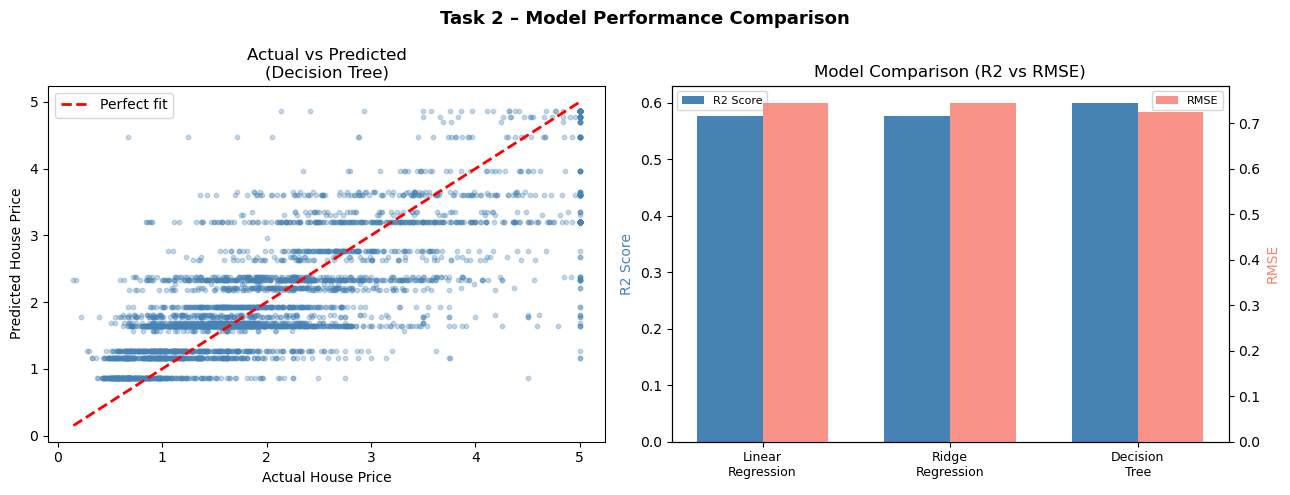


Best Model : Decision Tree
R2 Score   : 0.5997
RMSE       : 0.7242


In [8]:
# Step 8: Visual Performance Validation
best_name = results_df['R2 Score'].astype(float).idxmax()
y_pred    = preds[best_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Task 2 – Model Performance Comparison', fontsize=13, fontweight='bold')

# --- Plot 1: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual House Price')
axes[0].set_ylabel('Predicted House Price')
axes[0].set_title(f'Actual vs Predicted\n({best_name})')
axes[0].legend()

# --- Plot 2: Model Comparison Bar Chart ---
mnames    = list(results.keys())
r2_vals   = [results[m]['R2 Score'] for m in mnames]
rmse_vals = [results[m]['RMSE']     for m in mnames]
x = np.arange(len(mnames))
w = 0.35

axes[1].bar(x - w/2, r2_vals, w, label='R2 Score', color='steelblue')
ax2 = axes[1].twinx()
ax2.bar(x + w/2, rmse_vals, w, label='RMSE', color='salmon', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([m.replace(' ', '\n') for m in mnames], fontsize=9)
axes[1].set_ylabel('R2 Score', color='steelblue')
ax2.set_ylabel('RMSE', color='salmon')
axes[1].set_title('Model Comparison (R2 vs RMSE)')
axes[1].legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBest Model : {best_name}')
print(f'R2 Score   : {results[best_name]["R2 Score"]}')
print(f'RMSE       : {results[best_name]["RMSE"]}')

## Conclusion

| Model | RMSE | R² Score |
|---|---|---|
| Linear Regression | — | — |
| Ridge Regression  | — | — |
| Decision Tree     | — | — |

*(Fill in values from your results_df output above)*

**Selected Model:** The model with the highest R² and lowest RMSE is the best choice.
- Higher R² → explains more variance in house prices  
- Lower RMSE → smaller average prediction error